# per-residue attribution task

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import scipy.stats
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
from joblib import Parallel, delayed
import os, glob, joblib, gc, esm , torch, ast, numpy as np, pandas as pd

In [ ]:
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV,RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import roc_auc_score
from scipy.stats import randint, uniform

## select protein-coding gene

In [ ]:
gene_name='rpsL'
# pick the reference CDS protein sequence
ref_seqs=pd.read_csv('./data/catalog/protein_sequences.csv')
ref_protein = ref_seqs.loc[ref_seqs['gene'] == gene_name, 'protein_sequence'].values

In [ ]:
#load the gene sequence file
gene_sequences=pd.read_csv(f"./data/sequence_data_csv/{gene_name}_combined_sequence_data.csv")
gene_sequences_filtered = gene_sequences[gene_sequences["Frameshift_Mutation"] == 0].copy()
# Ensure required columns exist
if "Protein_Sequence" not in gene_sequences_filtered.columns:
    raise ValueError("CSV file must contain a 'Protein_Sequence' column.")

## load pretrained model

In [ ]:
# Assuming Random Forest performed best and saved
model_names = ["rf", "svr", "knn"]
model_paths = {
    "rf":  f"./trained_models/{gene_name}_best_rf_model.joblib",
    "svr": f"./trained_models/{gene_name}_best_svr_model.joblib",
    "knn": f"./trained_models/{gene_name}_best_knn_model.joblib"
}


In [ ]:
#since three models use same embedding - no need to compute baseline preds thrice
model = joblib.load(f"./trained_models/{gene_name}_best_rf_model.joblib")
mean_glob   = f"data/embeddings/{gene_name}/mean/{gene_name}_mean_chunk_*.npz"
out_dir     = f"baseline_preds/{gene_name}_base_preds_chunks"
os.makedirs(out_dir, exist_ok=True)

mean_paths  = sorted(glob.glob(mean_glob))

total = 0
for path in tqdm(mean_paths, desc="baseline preds"):
    z       = np.load(path)                           # identifier, mean_embedding
    X_mean  = z["mean_embedding"]                     # (n_i, 320)
    preds   = model.predict(X_mean).astype("float32")

    chunk_id = os.path.basename(path).split("_")[-1].split(".")[0]
    np.save(f"{out_dir}/base_preds_chunk_{chunk_id}.npy", preds)

    total += len(preds)

print("baseline predictions written for", total, "sequences")


In [ ]:
#check 0 indexing
import numpy as np
import glob
    
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

# gene_name = "katG"  # or whichever gene you're checking
token_npzs = sorted(glob.glob(f"data/embeddings/{gene_name}/token/{gene_name}_tok_chunk_*.npz"))

for f in token_npzs:
    z = np.load(f)
    tokens = z["tokens"]  # shape: (n_samples, L_PAD, 320)
    print(f"{f}: {tokens.shape}")
    

    tokens = z["tokens"]
    ids = z["identifier"]

    # Check against original protein sequence
    seq_df = pd.read_csv(f"data/sequence_data_csv/{gene_name}_combined_sequence_data.csv").set_index("Filename")
    first_id = ids[0]
    first_seq = seq_df.loc[first_id, "Protein_Sequence"]
    print("First 10 amino acids:", first_seq[:10])
    print("Token shape:", tokens.shape)
    print("Token 0 first 10:", tokens[0, :10].shape)
    break



In [ ]:
import numpy as np, glob

tok_paths = sorted(glob.glob(f"./data/embeddings/{gene_name}/token/{gene_name}_tok_chunk_*.npz"))

#check all sequences and select max length as seq len
seq_len = 0 
for p in tok_paths: 
    with np.load(p, allow_pickle=True) as z: 
        seq_len = max(seq_len, max(t.shape[0] for t in z["tokens"]))
        print("seq_len =", seq_len)

# embed_dim is always 320 for ESM‑2 T6
embed_dim = 320


#sanity check
assert all(
    all(t.shape[0] in {seq_len, seq_len-1} for t in np.load(p, allow_pickle=True)["tokens"])
    for p in tok_paths
), "Found a sequence longer than expected — adjust seq_len!"






In [41]:

tok_glob   = f"./data/embeddings/{gene_name}/token/{gene_name}_tok_chunk_*.npz"
# ------------------------------------------------------------------
# 1) Collect chunk paths
# ------------------------------------------------------------------
tok_paths = sorted(glob.glob(tok_glob))
assert tok_paths, "No *_tok_chunk_*.npz files found"

with np.load(tok_paths[0], mmap_mode="r") as z0:
    seq_len = z0["tokens"].shape[1]
inv = 1.0 / (seq_len - 1)
print(f"L (padded length) = {seq_len}")

# ------------------------------------------------------------------
# 2) Load mean-pools & base predictions
# ------------------------------------------------------------------
mean_pools, base_preds, chunk_sizes = [], [], []
print("loading baseline predictions …")
for tok_p in tqdm(tok_paths):
    with np.load(tok_p, mmap_mode="r") as z:
        toks = z["tokens"]
        mp = toks.mean(axis=1, dtype=np.float32)

    chunk_id = os.path.basename(tok_p).split("_")[-1].split(".")[0]
    pred_path = f"baseline_preds/{gene_name}_base_preds_chunks/base_preds_chunk_{chunk_id}.npy"
    preds = np.load(pred_path, mmap_mode="r")

    mean_pools.append(mp)
    base_preds.append(preds.astype(np.float32))
    chunk_sizes.append(len(preds))

N_total = int(np.sum(chunk_sizes))
print("Total sequences:", N_total)

L (padded length) = 124
loading baseline predictions …


100%|██████████| 7/7 [00:07<00:00,  1.01s/it]

Total sequences: 6542


In [42]:
# ------------------------------------------------------------------
# 3) LOO Importance Calculation (one residue)
# ------------------------------------------------------------------
def importance_for_residue(res_idx: int) -> float:
    abs_sum = 0.0
    for tok_p in tok_paths:
        chunk_id = os.path.basename(tok_p).split("_")[-1].split(".")[0]
        base_path = f"baseline_preds/{gene_name}_base_preds_chunks/base_preds_chunk_{chunk_id}.npy"
        base_preds = np.load(base_path, mmap_mode="r")

        with np.load(tok_p, mmap_mode="r") as z:
            toks = z["tokens"]
            mp   = toks.mean(axis=1, dtype=np.float32)
            rvec = toks[:, res_idx, :]
            masked = (seq_len * mp - rvec) * inv

        preds_masked = model.predict(masked)
        abs_sum += np.abs(base_preds - preds_masked).sum(dtype=np.float64)

        del base_preds, mp, rvec, masked, preds_masked, toks
        gc.collect()

    return abs_sum / N_total


In [43]:
# ------------------------------------------------------------------
# CONFIG
# # ------------------------------------------------------------------

n_jobs     = 4
BATCH_SIZE = 10  # adjust as needed (10–20 is often good)
model.named_steps["model"].n_jobs = -1  # enable internal RF parallelism

In [44]:
def plot_global_importance(residue_importance_df, model_tag):
    plt.figure(figsize=(15, 5))
    plt.bar(residue_importance_df["Residue_Position"], residue_importance_df["Importance"], color='skyblue')
    plt.xlabel("Residue Position")
    plt.ylabel("Global Importance Score")
    plt.title(f"Global Residue Importance (All Chunks) for {gene_name}")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.savefig(f"residue_importance/{gene_name}_{model_tag}global_residue_importance.png")
    plt.show()



Running importance for RF model


LOO (rf):   8%|▊         | 1/13 [00:19<03:55, 19.60s/it]

Saved up to residue 9 → residue_importance/rpsL_rf_residue_importances_loo.npy


LOO (rf):  15%|█▌        | 2/13 [00:38<03:32, 19.36s/it]

Saved up to residue 19 → residue_importance/rpsL_rf_residue_importances_loo.npy


...

Saved up to residue 109 → residue_importance/rpsL_rf_residue_importances_loo.npy


LOO (rf):  92%|█████████▏| 12/13 [03:47<00:19, 19.17s/it]

Saved up to residue 119 → residue_importance/rpsL_rf_residue_importances_loo.npy


LOO (rf): 100%|██████████| 13/13 [03:58<00:00, 18.34s/it]

Saved up to residue 123 → residue_importance/rpsL_rf_residue_importances_loo.npy

Top 5 positions for ethR by LOO importance:
    Residue_Position  Importance
0                  0    0.030889
77                77    0.026735
73                73    0.017727
53                53    0.013711
38                38    0.013620
Residue importance saved for RF model to: residue_importance/rpsL_rf_global_residue_importance_all_chunks.csv


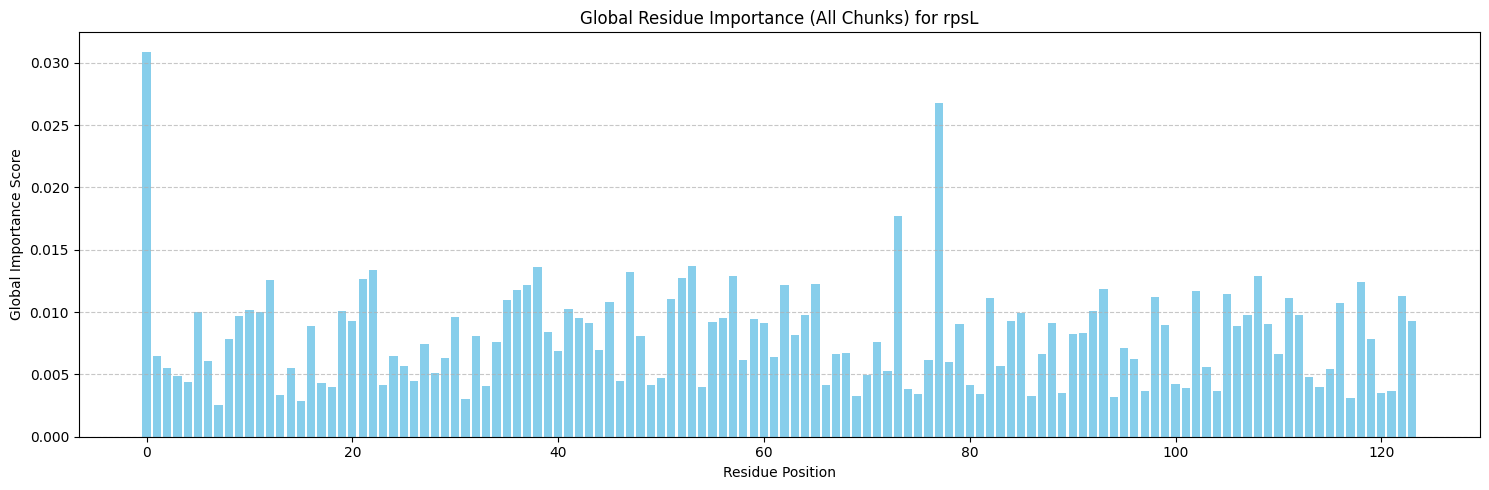


Running importance for SVR model


LOO (svr):   8%|▊         | 1/13 [00:13<02:45, 13.80s/it]

Saved up to residue 9 → residue_importance/rpsL_svr_residue_importances_loo.npy


LOO (svr):  15%|█▌        | 2/13 [00:27<02:32, 13.86s/it]

Saved up to residue 19 → residue_importance/rpsL_svr_residue_importances_loo.npy


...

Saved up to residue 109 → residue_importance/rpsL_svr_residue_importances_loo.npy


LOO (svr):  92%|█████████▏| 12/13 [02:44<00:13, 13.58s/it]

Saved up to residue 119 → residue_importance/rpsL_svr_residue_importances_loo.npy


LOO (svr): 100%|██████████| 13/13 [02:53<00:00, 13.36s/it]

Saved up to residue 123 → residue_importance/rpsL_svr_residue_importances_loo.npy

Top 5 positions for ethR by LOO importance:
    Residue_Position  Importance
0                  0    0.019668
60                60    0.011948
17                17    0.011875
51                51    0.011575
70                70    0.011567
Residue importance saved for SVR model to: residue_importance/rpsL_svr_global_residue_importance_all_chunks.csv


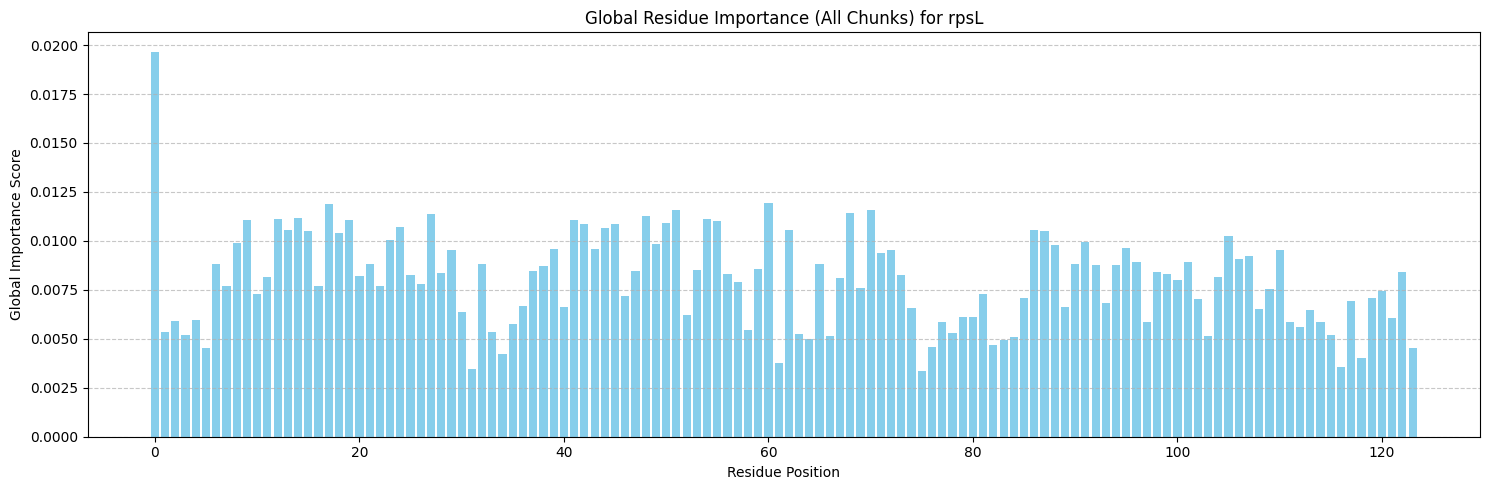


Running importance for KNN model


LOO (knn):   8%|▊         | 1/13 [00:21<04:12, 21.01s/it]

Saved up to residue 9 → residue_importance/rpsL_knn_residue_importances_loo.npy


LOO (knn):  15%|█▌        | 2/13 [00:37<03:24, 18.57s/it]

Saved up to residue 19 → residue_importance/rpsL_knn_residue_importances_loo.npy


...

Saved up to residue 109 → residue_importance/rpsL_knn_residue_importances_loo.npy


LOO (knn):  92%|█████████▏| 12/13 [03:29<00:18, 18.13s/it]

Saved up to residue 119 → residue_importance/rpsL_knn_residue_importances_loo.npy


LOO (knn): 100%|██████████| 13/13 [03:42<00:00, 17.14s/it]

Saved up to residue 123 → residue_importance/rpsL_knn_residue_importances_loo.npy

Top 5 positions for ethR by LOO importance:
    Residue_Position  Importance
62                62    0.010121
86                86    0.010121
66                66    0.010121
64                64    0.010121
75                75    0.010121
Residue importance saved for KNN model to: residue_importance/rpsL_knn_global_residue_importance_all_chunks.csv


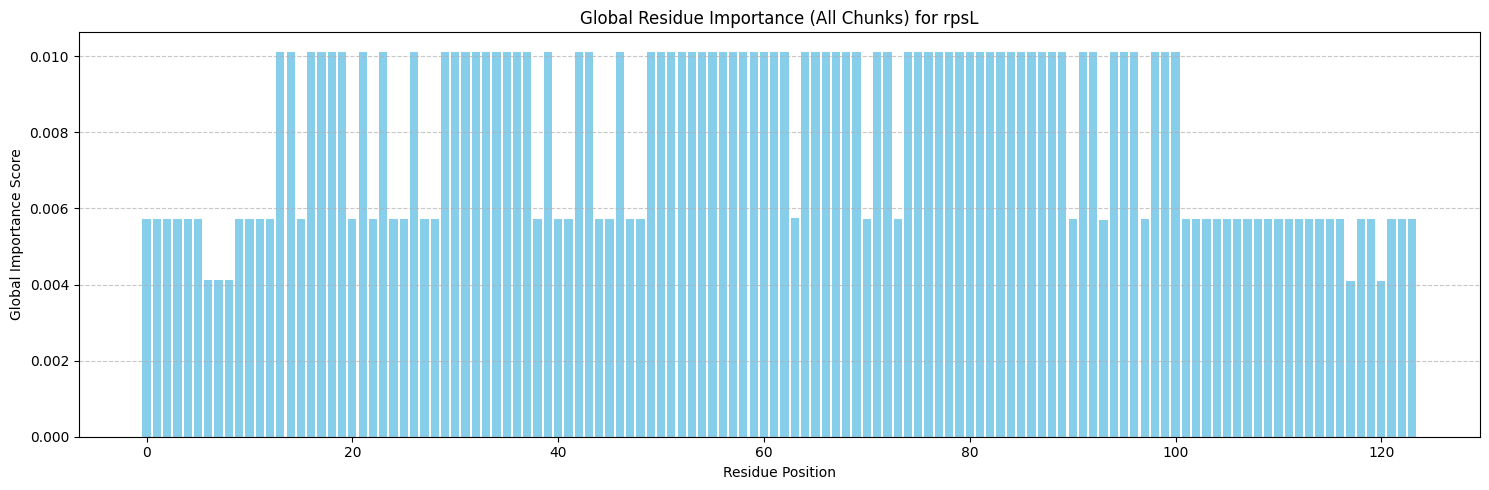

In [45]:
#residue importance for all three saved models 
from joblib import load
for model_tag in model_names:
    print(f"\nRunning importance for {model_tag.upper()} model")
    
    model = load(model_paths[model_tag])
    model.named_steps["model"].n_jobs = -1 if hasattr(model.named_steps["model"], "n_jobs") else None
    
    # Output path specific to model
    out_path = f"residue_importance/{gene_name}_{model_tag}_residue_importances_loo.npy"
    csv_path = f"residue_importance/{gene_name}_{model_tag}_global_residue_importance_all_chunks.csv"

    # Resume logic
    if os.path.exists(out_path):
        residue_importances = np.load(out_path).tolist()
        start_idx = len(residue_importances)
        print(f"Resuming from residue {start_idx}")
    else:
        residue_importances = []
        start_idx = 0

    for start in tqdm(range(start_idx, seq_len, BATCH_SIZE), desc=f"LOO ({model_tag})"):
        end = min(start + BATCH_SIZE, seq_len)

        scores = Parallel(n_jobs=12, backend="threading")(
            delayed(importance_for_residue)(idx) for idx in range(start, end)
        )

        residue_importances.extend(scores)
        np.save(out_path, np.asarray(residue_importances, dtype=np.float32))
        print(f"Saved up to residue {end - 1} → {out_path}")

    # Final normalization + CSV
    residue_importances = np.asarray(residue_importances, dtype=np.float32)
    residue_importances /= residue_importances.sum()
    np.save(out_path, residue_importances)
    # Save residue importance
    residue_df = pd.DataFrame({
        "Residue_Position": np.arange(seq_len),
        "Importance": residue_importances
    })
    # Sort by importance, highest first
    residue_df_sorted = residue_df.sort_values("Importance", ascending=False)
    print(f"\nTop 5 positions for {gene} by LOO importance:")
    print(residue_df_sorted.head(5))
    
    residue_df.to_csv(csv_path, index=False)
    print(f"Residue importance saved for {model_tag.upper()} model to: {csv_path}")
    #plot global importance
    plot_global_importance(residue_df, model_tag)
    #check catalog residue matching
    
    

In [11]:
# import pandas as pd

# # Load the file
# df = pd.read_csv("residue_importance/esm_classical/katG_global_residue_importance_all_chunks.csv")  # Use sep="\t" if it's tab-separated
# print(df.columns)

# # Sort by Residue_Position
# df_sorted = df.sort_values(by="Importance").reset_index(drop=True)
# df_sorted.head(30)

# # # Save the sorted file
# # df_sorted.to_csv("residue_importance/esm_classical/katG_global_residue_importance_all_chunks.csv", index=False)


Index(['Residue_Position', 'Importance'], dtype='object')


,Residue_Position,Importance
0,421,0.000691
1,451,0.000724
2,83,0.000731
3,395,0.000734
4,417,0.000737
5,386,0.000747
6,6,0.000774
7,88,0.000785
8,424,0.000787
9,81,0.000790


In [6]:
import pandas as pd
import numpy as np
from pathlib import Path


# Only retain variants with high-confidence labels ('1' or '2') AND intersectional == True
allowed_confidences = ['1) Assoc w R', '2) Assoc w R - Interim']
catalog_df = pd.read_csv("./data/filtered_variants_output.csv")

catalog_df = catalog_df[
    (catalog_df["confidence"].isin(allowed_confidences)) &
    (catalog_df["intersectional"] == True)
].copy()

# Ensure amino acid positions are integer type
catalog_df["aa_pos"] = catalog_df["aa_pos"].astype(int)-1

# -------------------------------
# Setup
# -------------------------------
importance_dir = Path("residue_importance/esm_classical")
# percentiles = [10, 20, 30, 50, 100]

percentiles = [10]
GENE_LIST = ['rpoB', 'rpsL', 'tlyA', 'pncA', 'eis', 'gid', 'katG', 'inhA', 'embA', 'embB', 'embC', 'gyrB', 'gyrA', 'ethA', 'ethR']

# Create a list to store results
all_rows = []

# -------------------------------
# Precision-recall computation
# -------------------------------
def compute_precision_recall(variants_df, important_positions):
    """
    Computes number of true positives, precision, and recall.

    Args:
        variants_df (pd.DataFrame): WHO catalog subset for the given gene.
        important_positions (set): Residue indices predicted as important.

    Returns:
        tuple: (true_positives, precision, recall)
    """
    if variants_df.empty or not important_positions:
        return 0, 0, 0

    true_positions = set(variants_df["aa_pos"])
    true_positives = len(true_positions.intersection(important_positions))
    
    total_predictions = len(important_positions)

    precision = true_positives / total_predictions if total_predictions > 0 else 0

    total_actual_positives = len(true_positions)
    recall = true_positives / total_actual_positives if total_actual_positives > 0 else 0

    return true_positives, precision, recall
# -------------------------------
# Evaluation loop
# -------------------------------
for gene in GENE_LIST:
    variants_gene_df = catalog_df[catalog_df["gene"].str.lower() == gene.lower()]

    total_actual_positives = len(np.unique(variants_gene_df["aa_pos"]))
    print(f"Total confirmed resistance positions for {gene}: {total_actual_positives}")

    csv_path = importance_dir / f"{gene}_global_residue_importance_all_chunks.csv"
    if not csv_path.exists():
        print(f"Missing: {csv_path}")
        continue

    imp_df = pd.read_csv(csv_path)
    imp_df_sorted = imp_df.sort_values("Importance", ascending=False)

    for k in percentiles:

        topk_df=imp_df_sorted.head(k)
        important_positions = set(topk_df["Residue_Position"])

        tp, precision, recall = compute_precision_recall(variants_gene_df, important_positions)
        f1 = 2 * (precision * recall) / (precision + recall + 1e-8)

        # Find identified variants
        who_gene_df = catalog_df[
            (catalog_df["gene"].str.lower() == gene.lower()) &
            (catalog_df["confidence"].isin(allowed_confidences)) &
            (catalog_df["intersectional"] == True)
        ].copy()

        identified_variants = who_gene_df[
            who_gene_df["aa_pos"].isin(important_positions)
        ]["variant"].tolist()

        identified_variants_str = ", ".join(identified_variants) if identified_variants else "None"

        # Save row for each k
        all_rows.append({
            "gene": gene,
            "Total_Resistance_Positions": total_actual_positives,
            "k": k,  #
            "TP": tp,
            "precision": precision,
            "recall": recall,
            "F1": f1,
            "identified_variants": identified_variants_str
        })




Total confirmed resistance positions for rpoB: 26
Total confirmed resistance positions for rpsL: 2
Total confirmed resistance positions for tlyA: 2
Total confirmed resistance positions for pncA: 95
Total confirmed resistance positions for eis: 0
Total confirmed resistance positions for gid: 8
Total confirmed resistance positions for katG: 2
Total confirmed resistance positions for inhA: 1
Total confirmed resistance positions for embA: 0
Missing: residue_importance/esm_classical/embA_global_residue_importance_all_chunks.csv
Total confirmed resistance positions for embB: 6
Total confirmed resistance positions for embC: 0
Missing: residue_importance/esm_classical/embC_global_residue_importance_all_chunks.csv
Total confirmed resistance positions for gyrB: 5
Total confirmed resistance positions for gyrA: 5
Total confirmed resistance positions for ethA: 9
Total confirmed resistance positions for ethR: 0


In [7]:
results_df = pd.DataFrame(all_rows)
results_df

,gene,Total_Resistance_Positions,k,TP,precision,recall,F1,identified_variants
0,rpoB,26,10,0,0.0,0.000000,0.000000,None
1,rpsL,2,10,0,0.0,0.000000,0.000000,None
2,tlyA,2,10,1,0.1,0.500000,0.166667,tlyA_p.Asn236Lys
3,pncA,95,10,2,0.2,0.021053,0.038095,"pncA_p.Gly78Asp, pncA_p.Gly78Ser, pncA_p.Gly78..."
4,eis,0,10,0,0.0,0.000000,0.000000,None
5,gid,8,10,0,0.0,0.000000,0.000000,None
6,katG,2,10,0,0.0,0.000000,0.000000,None
7,inhA,1,10,0,0.0,0.000000,0.000000,None
8,embB,6,10,1,0.1,0.166667,0.125000,"embB_p.Gly406Ala, embB_p.Gly406Asp, embB_p.Gly..."
9,gyrB,5,10,0,0.0,0.000000,0.000000,None


In [8]:
# -------------------------------
# Save final results
# -------------------------------

results_df.to_csv("residue_importance/esm_rf_k10.csv", index=False)
print("Saved summary to residue_importance/esm_rf_k10.csv")

Saved summary to residue_importance/esm_rf_k10.csv


In [ ]:
# Sort by 'gene' ascending and 'precision' descending
df_sorted = results_df.sort_values(by=['Gene', 'Precision'], ascending=[True, False])

# Now, for each gene, pick the first row (highest precision per gene)
best_per_gene = df_sorted.drop_duplicates(subset=['Gene'], keep='first').reset_index(drop=True)

print(best_per_gene)

In [ ]:
best_per_gene.to_csv("residue_importance/esm_rf_summary.csv", index=False)

## significance testing

In [1]:
import os
import glob
import gc
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from tqdm import tqdm
from multiprocessing import cpu_count

# ------------------ CONFIG ------------------
gene_name = "rpoB"
model_tag = "rf"
N_KEEP = 1000
BATCH_SIZE = 10
n_jobs = min(4, cpu_count())
EMBED_DIM = 320

In [2]:

# ------------------ Load Top-N R Sequences ------------------
gene_sequences = pd.read_csv(f"./data/sequence_data_csv/{gene_name}_combined_sequence_data.csv")
gene_sequences_filtered = gene_sequences[gene_sequences["Frameshift_Mutation"] == 0]
r_only = gene_sequences_filtered[gene_sequences_filtered["Phenotype"] == "R"]
top_r = r_only.head(N_KEEP)
top_ids = set(top_r["Filename"])

# ------------------ Setup Paths ------------------
model_fold_paths = sorted(glob.glob(f"statistical_test_results/prediction_task/esm_trained_models/{gene_name}_fold*_rf.joblib"))
assert model_fold_paths, "No fold-specific RF models found"

In [3]:

mean_glob = f"data/embeddings/{gene_name}/mean/{gene_name}_mean_chunk_*.npz"
mean_paths = sorted(glob.glob(mean_glob))

out_dir = f"statistical_test_results/PR_task/esm_rf/baseline_preds_top{N_KEEP}/{gene_name}_base_preds_chunks"
os.makedirs(out_dir, exist_ok=True)

In [4]:

# ------------------ Step 1: Filter + Predict ------------------
def save_filtered_chunks():
    total = 0
    for path in tqdm(mean_paths, desc="baseline preds"):
        z = np.load(path)
        ids = z["identifier"]
        mask = np.array([i in top_ids for i in ids])
        if not np.any(mask):
            continue

        X_mean = z["mean_embedding"][mask]
        chunk_id = os.path.basename(path).split("_")[-1].split(".")[0]
        np.save(f"{out_dir}/base_ids_chunk_{chunk_id}.npy", np.array(ids)[mask])
        np.save(f"{out_dir}/mean_chunk_{chunk_id}.npy", X_mean)
        total += len(X_mean)

    print("baseline mean embeddings written for", total, "sequences")

# ------------------ Step 2: Setup Token Files ------------------
def prepare_token_chunks():
    tok_glob = f"./data/embeddings/{gene_name}/token/{gene_name}_tok_chunk_*.npz"
    tok_paths = sorted(glob.glob(tok_glob))
    filtered_paths = []

    for path in tok_paths:
        with np.load(path, allow_pickle=True) as z:
            ids = z["identifier"]
            mask = np.array([i in top_ids for i in ids])
            if not np.any(mask):
                continue

            tokens = z["tokens"][mask]
            fname = f"./statistical_test_results/PR_task/esm_rf/top{N_KEEP}_{gene_name}_tok_chunk_{len(filtered_paths)}.npz"
            np.savez_compressed(fname, tokens=tokens)
            filtered_paths.append(fname)

    return filtered_paths

In [5]:
# ------------------ Step 3: Residue Importance ------------------
def compute_fold_importance(fold_idx, model_path, filtered_tok_paths, seq_len, inv, out_dir):
    model = joblib.load(model_path)
    model.named_steps["model"].n_jobs = -1

    out_path = f"statistical_test_results/PR_task/esm_rf/{gene_name}_rf_fold{fold_idx}_top{N_KEEP}_residue_importances_loo.npy"
    csv_path = f"statistical_test_results/PR_task/esm_rf/{gene_name}_rf_fold{fold_idx}_top{N_KEEP}_global_residue_importance_all_chunks.csv"

    def importance_for_residue(res_idx):
        abs_sum = 0.0
        for chunk_id, p in enumerate(filtered_tok_paths):
            base_mean = np.load(f"{out_dir}/mean_chunk_{chunk_id}.npy", mmap_mode="r")
            with np.load(p, mmap_mode="r") as z:
                toks = z["tokens"]
                mp = toks.mean(axis=1, dtype=np.float32)
                rvec = toks[:, res_idx, :]
                masked = (seq_len * mp - rvec) * inv
            preds_masked = model.predict(masked)
            base_preds = model.predict(base_mean)
            abs_sum += np.abs(base_preds - preds_masked).sum(dtype=np.float64)
        return abs_sum / N_total

    residue_importances = []
    for start in tqdm(range(0, seq_len, BATCH_SIZE), desc=f"LOO Importance Fold {fold_idx}"):
        end = min(start + BATCH_SIZE, seq_len)
        scores = Parallel(n_jobs=n_jobs)(
            delayed(importance_for_residue)(idx) for idx in range(start, end)
        )
        residue_importances.extend(scores)
        np.save(out_path, np.asarray(residue_importances, dtype=np.float32))

    residue_importances = np.asarray(residue_importances, dtype=np.float32)
    residue_importances /= residue_importances.sum()
    np.save(out_path, residue_importances)

    residue_df = pd.DataFrame({
        "Residue_Position": np.arange(seq_len),
        "Importance": residue_importances
    })
    residue_df.to_csv(csv_path, index=False)

    print(f"Saved Fold {fold_idx} LOO importance for {gene_name} (top {N_KEEP} R-only)")


In [ ]:

# ------------------ Run All Steps ------------------
save_filtered_chunks()
filtered_tok_paths = prepare_token_chunks()

with np.load(filtered_tok_paths[0]) as z:
    seq_len = z["tokens"].shape[1]
inv = 1.0 / (seq_len - 1)

mean_pools, chunk_sizes = [], []
for path in filtered_tok_paths:
    with np.load(path) as z:
        toks = z["tokens"]
        mp = toks.mean(axis=1, dtype=np.float32)
        mean_pools.append(mp)
        chunk_sizes.append(len(mp))
N_total = int(np.sum(chunk_sizes))

# ------------------ Parallel Run Across Folds ------------------
Parallel(n_jobs=len(model_fold_paths))(
    delayed(compute_fold_importance)(fold_idx + 1, model_path, filtered_tok_paths, seq_len, inv, out_dir)
    for fold_idx, model_path in enumerate(model_fold_paths)
)


baseline preds: 100%|██████████| 16/16 [00:00<00:00, 89.15it/s]


baseline mean embeddings written for 1000 sequences


LOO Importance Fold 2:  19%|█▉        | 23/118 [17:03<1:09:01, 43.60s/it]

In [ ]:

# ------------------- CONFIG -------------------
# gene_name = "tlyA"
N_KEEP = 1000
importance_dir = "statistical_test_results/PR_task/esm_rf"
catalog_path = "./data/filtered_variants_output.csv"
out_dir = "statistical_test_results/PR_task/esm_rf"
os.makedirs(out_dir, exist_ok=True)

# ------------------- Load WHO Catalog -------------------
allowed_confidences = ['1) Assoc w R', '2) Assoc w R - Interim']
catalog_df = pd.read_csv(catalog_path)
catalog_df = catalog_df[
    (catalog_df["confidence"].isin(allowed_confidences)) &
    (catalog_df["intersectional"] == True)
].copy()
catalog_df["aa_pos"] = catalog_df["aa_pos"].astype(int) - 1


In [ ]:

# ------------------- Evaluation Function -------------------
def compute_precision_recall(variants_df, important_positions):
    if variants_df.empty or not important_positions:
        return 0, 0, 0

    true_positions = set(variants_df["aa_pos"])
    true_positives = len(true_positions.intersection(important_positions))

    total_predictions = len(important_positions)
    precision = true_positives / total_predictions if total_predictions > 0 else 0
    total_actual_positives = len(true_positions)
    recall = true_positives / total_actual_positives if total_actual_positives > 0 else 0

    return true_positives, precision, recall

# ------------------- Evaluation Loop -------------------
k_vals = [10]
all_rows = []

variants_gene_df = catalog_df[catalog_df["gene"].str.lower() == gene_name.lower()]
total_actual_positives = len(np.unique(variants_gene_df["aa_pos"]))

for fold in range(1, 6):
    imp_path = os.path.join(
        importance_dir,
        f"{gene_name}_rf_fold{fold}_top{N_KEEP}_global_residue_importance_all_chunks.csv"
    )
    if not os.path.exists(imp_path):
        print(f"Missing: {imp_path}")
        continue

    imp_df = pd.read_csv(imp_path)
    imp_df_sorted = imp_df.sort_values("Importance", ascending=False)

    for k in k_vals:
        topk_df = imp_df_sorted.head(k)
        important_positions = set(topk_df["Residue_Position"])

        tp, precision, recall = compute_precision_recall(variants_gene_df, important_positions)
        f1 = 2 * (precision * recall) / (precision + recall + 1e-8)

        matched_df = variants_gene_df[variants_gene_df["aa_pos"].isin(important_positions)]
        identified_variants = matched_df.drop_duplicates("aa_pos")["variant"].tolist()
        identified_variants_str = ", ".join(identified_variants) if identified_variants else "None"

        all_rows.append({
            "gene": gene_name,
            "fold": fold,
            "k": k,
            "TP": tp,
            "Total_Resistance_Positions": total_actual_positives,
            "precision": precision,
            "recall": recall,
            "F1": f1,
            "identified_variants": identified_variants_str
        })




In [ ]:
# ------------------- Save Results -------------------
out_path = os.path.join(out_dir, f"{gene_name}_rf_top{N_KEEP}_pr_per_fold.csv")
pd.DataFrame(all_rows).to_csv(out_path, index=False)
print(f" Precision-recall evaluation saved to: {out_path}")